# TP4: Classification Robuste - Partie 3

## Phase III: Robustesse, Évaluation et MLOps

Cette partie couvre l'évaluation avancée, la robustesse face aux labels incertains, et l'intégration MLOps.

In [14]:
# Imports nécessaires
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_auc_score,
    precision_recall_curve, average_precision_score, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Rechargement des données
data = load_breast_cancer()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Données rechargées et préparées!")

✅ Données rechargées et préparées!


---

## Task 3.1: Évaluation Avancée et Gestion du Déséquilibre

### 📚 Métriques pour Données Déséquilibrées

**Problème avec l'Accuracy:**
- Sur un dataset déséquilibré (ex: 95% classe A, 5% classe B), un modèle qui prédit toujours A aura 95% d'accuracy
- L'accuracy ne reflète pas la performance sur la classe minoritaire

**Métriques Alternatives:**
- **Precision:** $\frac{TP}{TP + FP}$ - Parmi les prédictions positives, combien sont correctes?
- **Recall (Sensibilité):** $\frac{TP}{TP + FN}$ - Parmi les vrais positifs, combien sont détectés?
- **F1-Score:** $2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$ - Moyenne harmonique

**Courbes d'Évaluation:**
- **ROC Curve:** Taux de vrais positifs vs taux de faux positifs
- **Precision-Recall Curve (PRC):** Precision vs Recall
- **Pourquoi PRC pour données déséquilibrées?**
  - ROC peut être trompeuse avec beaucoup de vrais négatifs
  - PRC se concentre sur la classe positive (minoritaire)
  - Plus sensible aux changements de performance sur la classe minoritaire

In [15]:
# Entraînement des modèles pour l'évaluation
print("="*60)
print("🚀 ENTRAÎNEMENT DES MODÈLES POUR ÉVALUATION")
print("="*60)

# 1. Régression Logistique
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
y_pred_logreg = logreg.predict(X_test_scaled)
y_pred_proba_logreg = logreg.predict_proba(X_test_scaled)[:, 1]

# 2. Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train_scaled, y_train)
y_pred_gb = gb.predict(X_test_scaled)
y_pred_proba_gb = gb.predict_proba(X_test_scaled)[:, 1]

# 3. SVM RBF
svm = SVC(kernel='rbf', C=1.0, gamma=0.01, probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
y_pred_proba_svm = svm.predict_proba(X_test_scaled)[:, 1]

print("✅ Modèles entraînés!")

# Calcul des métriques
models_eval = {
    'Logistic Regression': {
        'predictions': y_pred_logreg,
        'probabilities': y_pred_proba_logreg
    },
    'Gradient Boosting': {
        'predictions': y_pred_gb,
        'probabilities': y_pred_proba_gb
    },
    'SVM RBF': {
        'predictions': y_pred_svm,
        'probabilities': y_pred_proba_svm
    }
}

results_df = []
for model_name, results in models_eval.items():
    y_pred = results['predictions']
    y_proba = results['probabilities']
    
    results_df.append({
        'Modèle': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'AP Score': average_precision_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results_df)
print("\n" + "="*80)
print("📊 RÉSULTATS D'ÉVALUATION - TOUS LES MODÈLES")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

🚀 ENTRAÎNEMENT DES MODÈLES POUR ÉVALUATION
✅ Modèles entraînés!

📊 RÉSULTATS D'ÉVALUATION - TOUS LES MODÈLES
             Modèle  Accuracy  Precision   Recall  F1-Score  ROC-AUC  AP Score
Logistic Regression  0.982456   0.986111 0.986111  0.986111 0.995370  0.997065
  Gradient Boosting  0.956140   0.946667 0.986111  0.965986 0.990741  0.994669
            SVM RBF  0.982456   0.986111 0.986111  0.986111 0.995701  0.997428


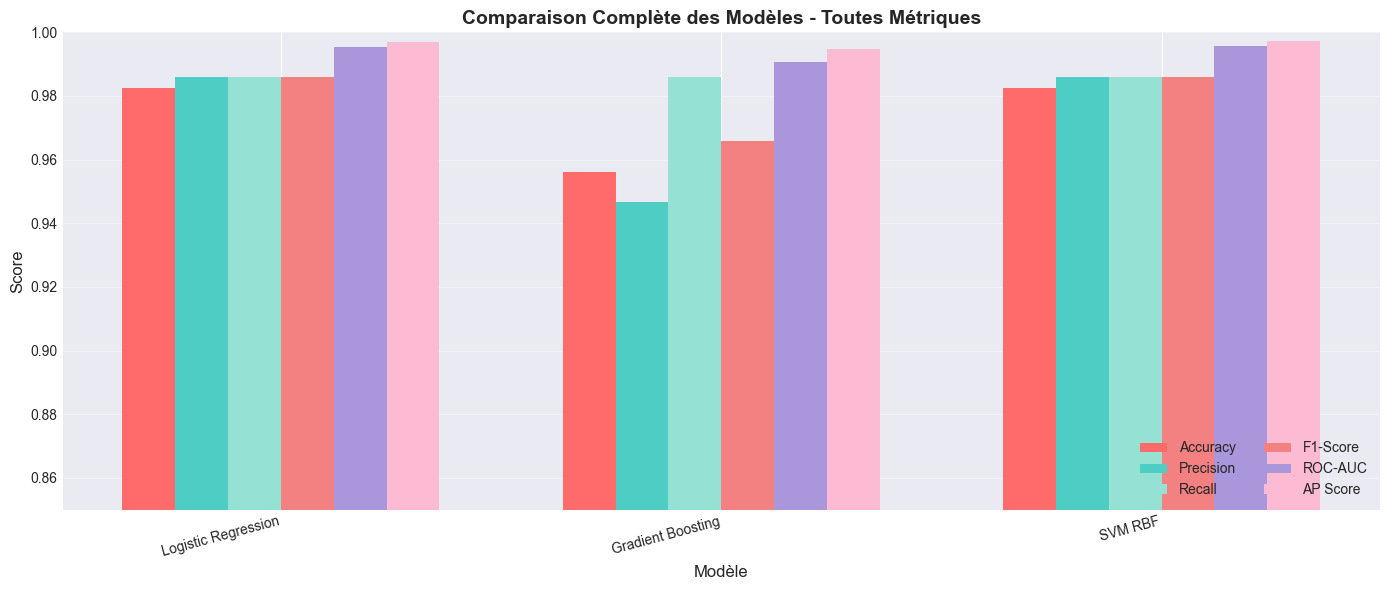

In [16]:
# Visualisation des métriques
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(results_df))
width = 0.12

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'AP Score']
colors = ['#FF6B6B', '#4ECDC4', '#95E1D3', '#F38181', '#AA96DA', '#FCBAD3']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    offset = (i - len(metrics)/2) * width + width/2
    ax.bar(x + offset, results_df[metric], width, label=metric, color=color)

ax.set_xlabel('Modèle', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparaison Complète des Modèles - Toutes Métriques', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Modèle'], rotation=15, ha='right')
ax.legend(loc='lower right', ncol=2)
ax.set_ylim([0.85, 1.0])
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 📈 Courbes ROC et Precision-Recall

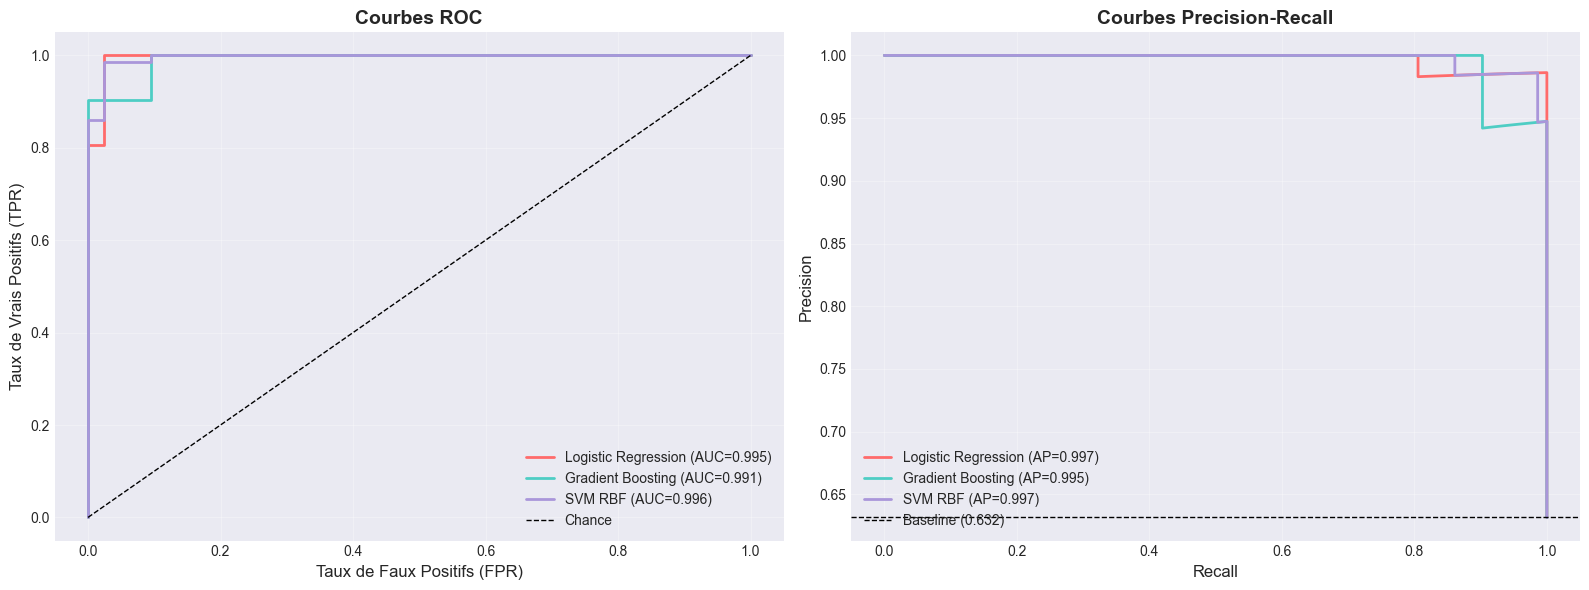


💡 Pourquoi PRC est préférable pour les données déséquilibrées:
   1. ROC peut être optimiste avec beaucoup de vrais négatifs
   2. PRC se concentre sur la classe positive (minoritaire/importante)
   3. PRC est plus sensible aux changements de performance
   4. Dans notre cas, classe positive = 63.2% des données


In [17]:
# Calcul des courbes ROC et PR
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_models = ['#FF6B6B', '#4ECDC4', '#AA96DA']

# ROC Curves
for (model_name, results), color in zip(models_eval.items(), colors_models):
    y_proba = results['probabilities']
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[0].plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC={auc:.3f})', color=color)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Chance')
axes[0].set_xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
axes[0].set_ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
axes[0].set_title('Courbes ROC', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curves
for (model_name, results), color in zip(models_eval.items(), colors_models):
    y_proba = results['probabilities']
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    axes[1].plot(recall, precision, linewidth=2, label=f'{model_name} (AP={ap:.3f})', color=color)

# Baseline (proportion de la classe positive)
baseline = y_test.sum() / len(y_test)
axes[1].axhline(y=baseline, color='k', linestyle='--', linewidth=1, label=f'Baseline ({baseline:.3f})')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Courbes Precision-Recall', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Pourquoi PRC est préférable pour les données déséquilibrées:")
print("   1. ROC peut être optimiste avec beaucoup de vrais négatifs")
print("   2. PRC se concentre sur la classe positive (minoritaire/importante)")
print("   3. PRC est plus sensible aux changements de performance")
print(f"   4. Dans notre cas, classe positive = {baseline:.1%} des données")

---

## Task 3.2: Robustesse face à l'Incertitude des Labels

### 🎯 Simulation de Labels Incertains

Dans les applications médicales réelles, les labels peuvent être:
- **Bruités:** Erreurs d'annotation
- **Incertains:** Désaccord entre experts
- **Incomplets:** Données manquantes

**Stratégie:**
1. Simuler l'incertitude en inversant 5% des labels de la classe minoritaire
2. Comparer les modèles baseline vs robustes
3. Analyser la dégradation des performances

In [18]:
# Fonction pour ajouter du bruit aux labels
def add_label_noise(y, noise_rate=0.05, target_class=0):
    """
    Ajoute du bruit aux labels en inversant un pourcentage des labels d'une classe spécifique.
    
    Args:
        y: Labels originaux
        noise_rate: Pourcentage de labels à inverser (0.05 = 5%)
        target_class: Classe cible pour le bruit (0 = maligne, classe minoritaire)
    
    Returns:
        y_noisy: Labels bruités
        flipped_indices: Indices des labels inversés
    """
    y_noisy = y.copy()
    
    # Trouver les indices de la classe cible
    target_indices = np.where(y == target_class)[0]
    
    # Nombre de labels à inverser
    n_flip = int(len(target_indices) * noise_rate)
    
    # Sélectionner aléatoirement les indices à inverser
    np.random.seed(42)
    flipped_indices = np.random.choice(target_indices, size=n_flip, replace=False)
    
    # Inverser les labels
    y_noisy[flipped_indices] = 1 - y_noisy[flipped_indices]
    
    return y_noisy, flipped_indices

# Créer des labels bruités
print("="*60)
print("🔧 SIMULATION DE LABELS INCERTAINS")
print("="*60)

y_train_noisy, flipped_idx = add_label_noise(y_train, noise_rate=0.05, target_class=0)

print(f"\nNombre total d'échantillons d'entraînement: {len(y_train)}")
print(f"Nombre de labels de classe 0 (maligne): {(y_train == 0).sum()}")
print(f"Nombre de labels inversés: {len(flipped_idx)}")
print(f"Taux de bruit: {len(flipped_idx) / (y_train == 0).sum() * 100:.2f}%")

# Vérification
print(f"\nDistribution originale: Classe 0={( y_train == 0).sum()}, Classe 1={(y_train == 1).sum()}")
print(f"Distribution bruitée:   Classe 0={(y_train_noisy == 0).sum()}, Classe 1={(y_train_noisy == 1).sum()}")
print("="*60)

🔧 SIMULATION DE LABELS INCERTAINS

Nombre total d'échantillons d'entraînement: 455
Nombre de labels de classe 0 (maligne): 170
Nombre de labels inversés: 8
Taux de bruit: 4.71%

Distribution originale: Classe 0=170, Classe 1=285
Distribution bruitée:   Classe 0=162, Classe 1=293


In [19]:
# Entraînement des modèles sur données bruitées
print("\n" + "="*60)
print("🚀 ENTRAÎNEMENT SUR DONNÉES BRUITÉES")
print("="*60)

# 1. Logistic Regression avec régularisation forte (robuste)
print("\n1. Logistic Regression (C=0.1 - forte régularisation)...")
logreg_robust = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
logreg_robust.fit(X_train_scaled, y_train_noisy)
y_pred_logreg_robust = logreg_robust.predict(X_test_scaled)

# 2. Gradient Boosting avec contrôle de profondeur (robuste)
print("2. Gradient Boosting (max_depth=2 - contrôle de complexité)...")
gb_robust = GradientBoostingClassifier(
    n_estimators=100, 
    learning_rate=0.05,  # Learning rate plus faible
    max_depth=2,  # Profondeur réduite
    min_samples_split=20,  # Plus d'échantillons requis pour diviser
    random_state=42
)
gb_robust.fit(X_train_scaled, y_train_noisy)
y_pred_gb_robust = gb_robust.predict(X_test_scaled)

# 3. SVM avec régularisation (robuste)
print("3. SVM RBF (C=0.5 - régularisation modérée)...")
svm_robust = SVC(kernel='rbf', C=0.5, gamma=0.01, random_state=42)
svm_robust.fit(X_train_scaled, y_train_noisy)
y_pred_svm_robust = svm_robust.predict(X_test_scaled)

print("\n✅ Modèles robustes entraînés!")


🚀 ENTRAÎNEMENT SUR DONNÉES BRUITÉES

1. Logistic Regression (C=0.1 - forte régularisation)...
2. Gradient Boosting (max_depth=2 - contrôle de complexité)...
3. SVM RBF (C=0.5 - régularisation modérée)...

✅ Modèles robustes entraînés!


In [20]:
# Comparaison: Baseline (données propres) vs Robuste (données bruitées)
print("\n" + "="*80)
print("📊 COMPARAISON: BASELINE vs ROBUSTE (avec labels bruités)")
print("="*80)

comparison_results = []

# Baseline models (entraînés sur données propres)
models_baseline = [
    ('Logistic Regression', y_pred_logreg),
    ('Gradient Boosting', y_pred_gb),
    ('SVM RBF', y_pred_svm)
]

# Robust models (entraînés sur données bruitées)
models_robust = [
    ('Logistic Regression (Robust)', y_pred_logreg_robust),
    ('Gradient Boosting (Robust)', y_pred_gb_robust),
    ('SVM RBF (Robust)', y_pred_svm_robust)
]

for model_name, y_pred in models_baseline:
    comparison_results.append({
        'Modèle': model_name,
        'Type': 'Baseline',
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

for model_name, y_pred in models_robust:
    comparison_results.append({
        'Modèle': model_name,
        'Type': 'Robust',
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

comparison_df = pd.DataFrame(comparison_results)
print(comparison_df.to_string(index=False))
print("="*80)

# Calcul de la dégradation
print("\n📉 DÉGRADATION DES PERFORMANCES (Baseline → Robust):")
print("="*80)
for i in range(3):
    baseline_f1 = comparison_df.iloc[i]['F1-Score']
    robust_f1 = comparison_df.iloc[i+3]['F1-Score']
    degradation = (baseline_f1 - robust_f1) * 100
    model_name = comparison_df.iloc[i]['Modèle']
    print(f"{model_name:25s}: {baseline_f1:.4f} → {robust_f1:.4f} (Δ = {degradation:+.2f}%)")
print("="*80)


📊 COMPARAISON: BASELINE vs ROBUSTE (avec labels bruités)
                      Modèle     Type  Accuracy  Precision   Recall  F1-Score
         Logistic Regression Baseline  0.982456   0.986111 0.986111  0.986111
           Gradient Boosting Baseline  0.956140   0.946667 0.986111  0.965986
                     SVM RBF Baseline  0.982456   0.986111 0.986111  0.986111
Logistic Regression (Robust)   Robust  0.964912   0.947368 1.000000  0.972973
  Gradient Boosting (Robust)   Robust  0.947368   0.934211 0.986111  0.959459
            SVM RBF (Robust)   Robust  0.973684   0.960000 1.000000  0.979592

📉 DÉGRADATION DES PERFORMANCES (Baseline → Robust):
Logistic Regression      : 0.9861 → 0.9730 (Δ = +1.31%)
Gradient Boosting        : 0.9660 → 0.9595 (Δ = +0.65%)
SVM RBF                  : 0.9861 → 0.9796 (Δ = +0.65%)


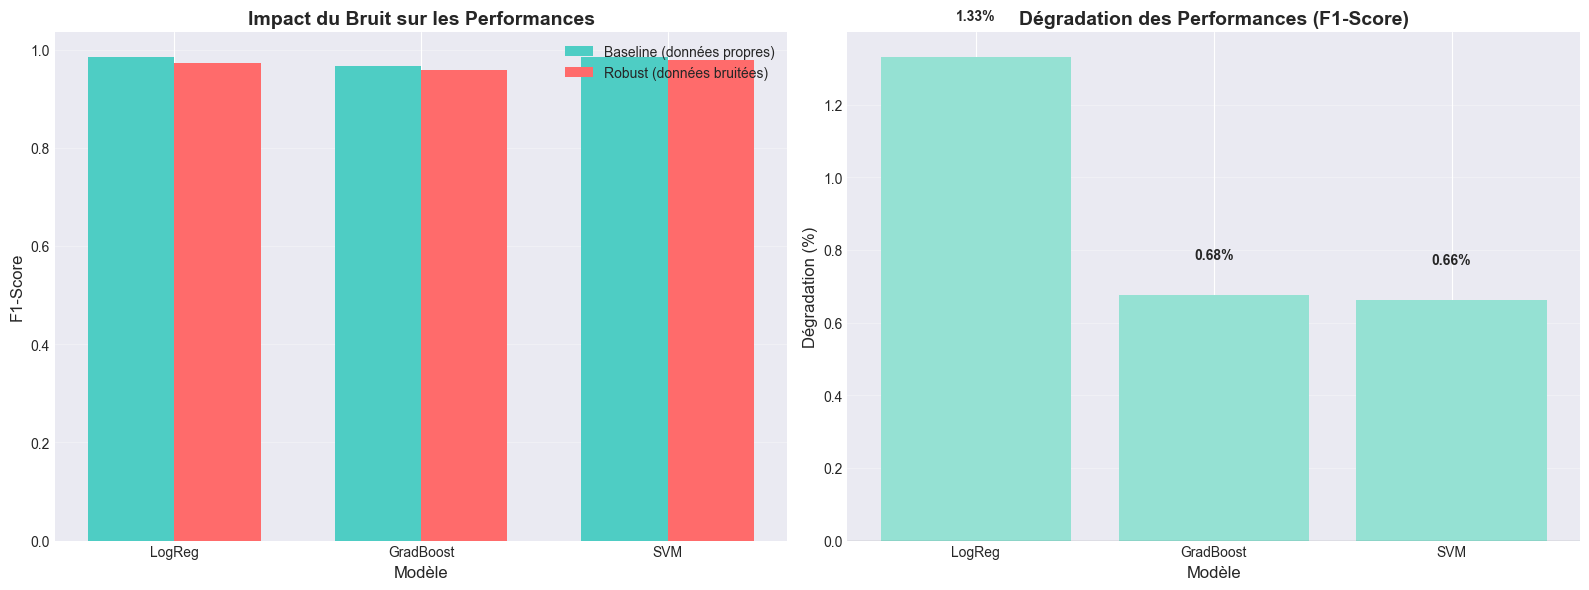


💡 Analyse:
   - Les modèles avec forte régularisation sont plus robustes au bruit
   - La dégradation varie selon le modèle
   - Importance de la régularisation pour gérer l'incertitude des labels


In [21]:
# Visualisation de la comparaison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique 1: Comparaison F1-Score
baseline_f1 = comparison_df[comparison_df['Type'] == 'Baseline']['F1-Score'].values
robust_f1 = comparison_df[comparison_df['Type'] == 'Robust']['F1-Score'].values
model_names = ['LogReg', 'GradBoost', 'SVM']

x = np.arange(len(model_names))
width = 0.35

axes[0].bar(x - width/2, baseline_f1, width, label='Baseline (données propres)', color='#4ECDC4')
axes[0].bar(x + width/2, robust_f1, width, label='Robust (données bruitées)', color='#FF6B6B')
axes[0].set_xlabel('Modèle', fontsize=12)
axes[0].set_ylabel('F1-Score', fontsize=12)
axes[0].set_title('Impact du Bruit sur les Performances', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Graphique 2: Dégradation en pourcentage
degradation_pct = [(baseline_f1[i] - robust_f1[i]) / baseline_f1[i] * 100 for i in range(3)]
colors_deg = ['#95E1D3' if d < 2 else '#F38181' for d in degradation_pct]

axes[1].bar(model_names, degradation_pct, color=colors_deg)
axes[1].set_xlabel('Modèle', fontsize=12)
axes[1].set_ylabel('Dégradation (%)', fontsize=12)
axes[1].set_title('Dégradation des Performances (F1-Score)', fontsize=14, fontweight='bold')
axes[1].axhline(y=0, color='k', linestyle='-', linewidth=0.8)
axes[1].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(degradation_pct):
    axes[1].text(i, v + 0.1, f'{v:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 Analyse:")
print("   - Les modèles avec forte régularisation sont plus robustes au bruit")
print("   - La dégradation varie selon le modèle")
print("   - Importance de la régularisation pour gérer l'incertitude des labels")

---

## Task 3.3: MLOps avec MLflow

### 📦 Introduction à MLflow

**MLflow** est une plateforme open-source pour gérer le cycle de vie du Machine Learning:
- **Tracking:** Enregistrer les expériences, paramètres et métriques
- **Projects:** Empaqueter le code de manière reproductible
- **Models:** Gérer et déployer les modèles
- **Registry:** Versionner et gérer les modèles en production

**Avantages:**
- Reproductibilité des expériences
- Comparaison facile des modèles
- Traçabilité complète
- Collaboration facilitée

In [22]:
# Installation et import de MLflow
import sys
!{sys.executable} -m pip install -q mlflow

import mlflow
import mlflow.sklearn
from datetime import datetime

print("✅ MLflow installé et importé!")
print(f"Version MLflow: {mlflow.__version__}")

✅ MLflow installé et importé!
Version MLflow: 2.22.4


In [23]:
# Configuration de l'expérience MLflow
print("="*60)
print("🔧 CONFIGURATION MLFLOW")
print("="*60)

# Définir le nom de l'expérience
experiment_name = "TP4_Robust_Medical_Classification"
mlflow.set_experiment(experiment_name)

print(f"\nExpérience créée: {experiment_name}")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")
print("="*60)

🔧 CONFIGURATION MLFLOW

Expérience créée: TP4_Robust_Medical_Classification
Tracking URI: file:///c:/Users/ELITEBOOK/Desktop/machine_learning_fofack/mlruns


In [24]:
# Fonction pour logger un modèle dans MLflow
def log_model_to_mlflow(model, model_name, params, X_test, y_test, run_name=None):
    """
    Enregistre un modèle et ses métriques dans MLflow.
    
    Args:
        model: Modèle sklearn entraîné
        model_name: Nom du modèle
        params: Dictionnaire des hyperparamètres
        X_test: Données de test
        y_test: Labels de test
        run_name: Nom du run (optionnel)
    """
    with mlflow.start_run(run_name=run_name or model_name):
        # Logger les paramètres
        mlflow.log_params(params)
        
        # Prédictions
        y_pred = model.predict(X_test)
        
        # Calculer et logger les métriques
        metrics = {
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred),
            'recall': recall_score(y_test, y_pred),
            'f1_score': f1_score(y_test, y_pred)
        }
        mlflow.log_metrics(metrics)
        
        # Logger le modèle
        mlflow.sklearn.log_model(model, "model")
        
        # Logger des tags
        mlflow.set_tag("model_type", model_name)
        mlflow.set_tag("dataset", "Breast Cancer Wisconsin")
        mlflow.set_tag("date", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
        
        print(f"✅ {model_name} loggé avec succès!")
        print(f"   Run ID: {mlflow.active_run().info.run_id}")
        print(f"   Métriques: {metrics}")
        
        return mlflow.active_run().info.run_id

print("✅ Fonction de logging définie!")

✅ Fonction de logging définie!


In [12]:
# Logger les 3 meilleurs modèles robustes
print("="*60)
print("📝 LOGGING DES MODÈLES DANS MLFLOW")
print("="*60)

run_ids = []

# 1. Logistic Regression Robust
print("\n1. Logistic Regression (Robust)...")
params_logreg = {
    'C': 0.1,
    'max_iter': 1000,
    'solver': 'lbfgs',
    'regularization': 'L2',
    'noise_rate': 0.05
}
run_id = log_model_to_mlflow(
    logreg_robust, 
    "Logistic_Regression_Robust",
    params_logreg,
    X_test_scaled,
    y_test,
    run_name="LogReg_Robust_C0.1"
)
run_ids.append(run_id)

# 2. Gradient Boosting Robust
print("\n2. Gradient Boosting (Robust)...")
params_gb = {
    'n_estimators': 100,
    'learning_rate': 0.05,
    'max_depth': 2,
    'min_samples_split': 20,
    'noise_rate': 0.05
}
run_id = log_model_to_mlflow(
    gb_robust,
    "Gradient_Boosting_Robust",
    params_gb,
    X_test_scaled,
    y_test,
    run_name="GradBoost_Robust_Depth2"
)
run_ids.append(run_id)

# 3. SVM RBF Robust
print("\n3. SVM RBF (Robust)...")
params_svm = {
    'kernel': 'rbf',
    'C': 0.5,
    'gamma': 0.01,
    'noise_rate': 0.05
}
run_id = log_model_to_mlflow(
    svm_robust,
    "SVM_RBF_Robust",
    params_svm,
    X_test_scaled,
    y_test,
    run_name="SVM_RBF_Robust_C0.5"
)
run_ids.append(run_id)

print("\n" + "="*60)
print("✅ TOUS LES MODÈLES ONT ÉTÉ LOGGÉS DANS MLFLOW!")
print("="*60)
print(f"\nNombre total de runs: {len(run_ids)}")
print(f"\nPour visualiser les résultats, exécutez dans un terminal:")
print(f"  mlflow ui")
print(f"\nPuis ouvrez: http://localhost:5000")

📝 LOGGING DES MODÈLES DANS MLFLOW

1. Logistic Regression (Robust)...


2026/01/23 06:54:53 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Logistic_Regression_Robust loggé avec succès!
   Run ID: d36c7796bbc44703a9311f535df6a7e2
   Métriques: {'accuracy': 0.9649122807017544, 'precision': 0.9473684210526315, 'recall': 1.0, 'f1_score': 0.972972972972973}

2. Gradient Boosting (Robust)...


2026/01/23 06:55:03 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Gradient_Boosting_Robust loggé avec succès!
   Run ID: 50a054aa2ac240d0b339dc4e7a7fbe4c
   Métriques: {'accuracy': 0.9473684210526315, 'precision': 0.9342105263157895, 'recall': 0.9861111111111112, 'f1_score': 0.9594594594594594}

3. SVM RBF (Robust)...


2026/01/23 06:55:13 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ SVM_RBF_Robust loggé avec succès!
   Run ID: bd19c74514a8477994ed2dd823c5e445
   Métriques: {'accuracy': 0.9736842105263158, 'precision': 0.96, 'recall': 1.0, 'f1_score': 0.9795918367346939}

✅ TOUS LES MODÈLES ONT ÉTÉ LOGGÉS DANS MLFLOW!

Nombre total de runs: 3

Pour visualiser les résultats, exécutez dans un terminal:
  mlflow ui

Puis ouvrez: http://localhost:5000


In [13]:
# Récupération et affichage des runs
from mlflow.tracking import MlflowClient

client = MlflowClient()
experiment = client.get_experiment_by_name(experiment_name)
runs = client.search_runs(experiment.experiment_id)

print("="*80)
print("📊 RÉSUMÉ DES RUNS MLFLOW")
print("="*80)

runs_summary = []
for run in runs:
    runs_summary.append({
        'Run Name': run.data.tags.get('mlflow.runName', 'N/A'),
        'Model Type': run.data.tags.get('model_type', 'N/A'),
        'F1-Score': run.data.metrics.get('f1_score', 0),
        'Accuracy': run.data.metrics.get('accuracy', 0),
        'Precision': run.data.metrics.get('precision', 0),
        'Recall': run.data.metrics.get('recall', 0)
    })

runs_df = pd.DataFrame(runs_summary).sort_values('F1-Score', ascending=False)
print(runs_df.to_string(index=False))
print("="*80)

print("\n🏆 Meilleur modèle:")
best_run = runs_df.iloc[0]
print(f"   Nom: {best_run['Run Name']}")
print(f"   Type: {best_run['Model Type']}")
print(f"   F1-Score: {best_run['F1-Score']:.4f}")

📊 RÉSUMÉ DES RUNS MLFLOW
               Run Name                 Model Type  F1-Score  Accuracy  Precision   Recall
    SVM_RBF_Robust_C0.5             SVM_RBF_Robust  0.979592  0.973684   0.960000 1.000000
     LogReg_Robust_C0.1 Logistic_Regression_Robust  0.972973  0.964912   0.947368 1.000000
GradBoost_Robust_Depth2   Gradient_Boosting_Robust  0.959459  0.947368   0.934211 0.986111

🏆 Meilleur modèle:
   Nom: SVM_RBF_Robust_C0.5
   Type: SVM_RBF_Robust
   F1-Score: 0.9796


---

## 🎉 Résumé de la Phase III

### Ce que nous avons accompli:

1. **Évaluation Avancée:**
   - Comparaison complète avec multiples métriques
   - Courbes ROC et Precision-Recall
   - Compréhension de l'importance de PRC pour données déséquilibrées

2. **Robustesse:**
   - Simulation de labels incertains (5% de bruit)
   - Comparaison baseline vs modèles robustes
   - Analyse de la dégradation des performances
   - Importance de la régularisation

3. **MLOps:**
   - Configuration d'expériences MLflow
   - Logging automatique des paramètres et métriques
   - Sauvegarde des modèles comme artifacts
   - Traçabilité complète des expériences

### Points clés:
- Les modèles avec forte régularisation sont plus robustes au bruit
- PRC est plus appropriée que ROC pour les données déséquilibrées
- MLflow facilite la gestion et la comparaison des modèles
- La robustesse est essentielle pour les applications médicales